In [12]:
import json
import os
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch

# --- Style: clean, publication-ready ---
sns.set_style("ticks")

# ColorBrewer Dark2: distinguishable, color-blind friendly
PALETTE = {"arXiv": "#0816D6", "PMCharts": "#D90202", "synthetic":
            "#5DE9EE"}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.fontsize": 8,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#cccccc",
    "font.size": 9,
    "grid.linewidth": 0.5,
    "grid.color": "#dddddd",
    "lines.linewidth": 1.2,
})

GROUNDTRUTH_DIR = Path("../data/groundtruth")
DATASETS = ["arXiv", "PMCharts", "synthetic"]

print("Librerie caricate.")
print(f"Directory groundtruth: {GROUNDTRUTH_DIR.resolve()}")

Librerie caricate.
Directory groundtruth: /home/giorgiomelch/VS_Workspace/about_chart_to_table/SciChartBench/data/groundtruth


In [2]:
def _count_unique(pts, key):
    """Count unique values for a key, stringifying unhashable values (e.g. dicts)."""
    seen = set()
    for p in pts:
        v = p.get(key)
        try:
            seen.add(v)
        except TypeError:
            seen.add(str(v))
    return len(seen)

records = []
for ds in DATASETS:
    ds_dir = GROUNDTRUTH_DIR / ds
    if not ds_dir.exists():
        print(f"Warning: {ds_dir} not found")
        continue
    for ct_dir in sorted(ds_dir.iterdir()):
        if not ct_dir.is_dir():
            continue
        chart_type = ct_dir.name
        for json_file in sorted(ct_dir.glob("*.json")):
            with open(json_file) as f:
                data = json.load(f)
            pts = data.get("data_points", [])
            # Heatmap: each (x, y) cell is an independent data point → use len(pts)
            # Other types: n_datapoints = unique x-axis positions
            if chart_type == "heatmap":
                n_series = 0
                n_x = len(pts)
            else:
                has_series = pts and "series_name" in pts[0]
                n_series = _count_unique(pts, "series_name") if has_series else 0
                n_x = _count_unique(pts, "x_value") if pts else 0
            records.append({
                "dataset": ds,
                "chart_type": chart_type,
                "filename": json_file.name,
                "n_datapoints": n_x,
                "n_series": n_series,
            })

df = pd.DataFrame(records)
print(f"Campioni totali: {len(df)}")
print(df.groupby(["dataset", "chart_type"]).size().unstack(fill_value=0))

Campioni totali: 1450
chart_type  bar  box  bubble  errorpoint  heatmap  histogram  line  pie  \
dataset                                                                   
PMCharts     50   50      50          50       50         50    50   50   
arXiv        50   50       0          50       50         50    50   50   
synthetic    50   50      50          50       50         50    50   50   

chart_type  radar  scatter  
dataset                     
PMCharts       50       50  
arXiv          50       50  
synthetic      50       50  


In [3]:
stats = (df.groupby("dataset")[["n_datapoints", "n_series"]]
           .agg(["mean", "median", "std", "max"])
           .round(1))
print("Statistiche di complessità per dataset")
stats

Statistiche di complessità per dataset


n_datapoints                  n_series                
                  mean median   std max     mean median  std max
dataset                                                         
PMCharts          11.2    8.0  10.2  64      1.6    1.0  1.3  11
arXiv             11.8    8.0  11.2  79      1.7    1.0  1.3   8
synthetic         10.7    7.0   7.5  49      1.4    1.0  1.0   4

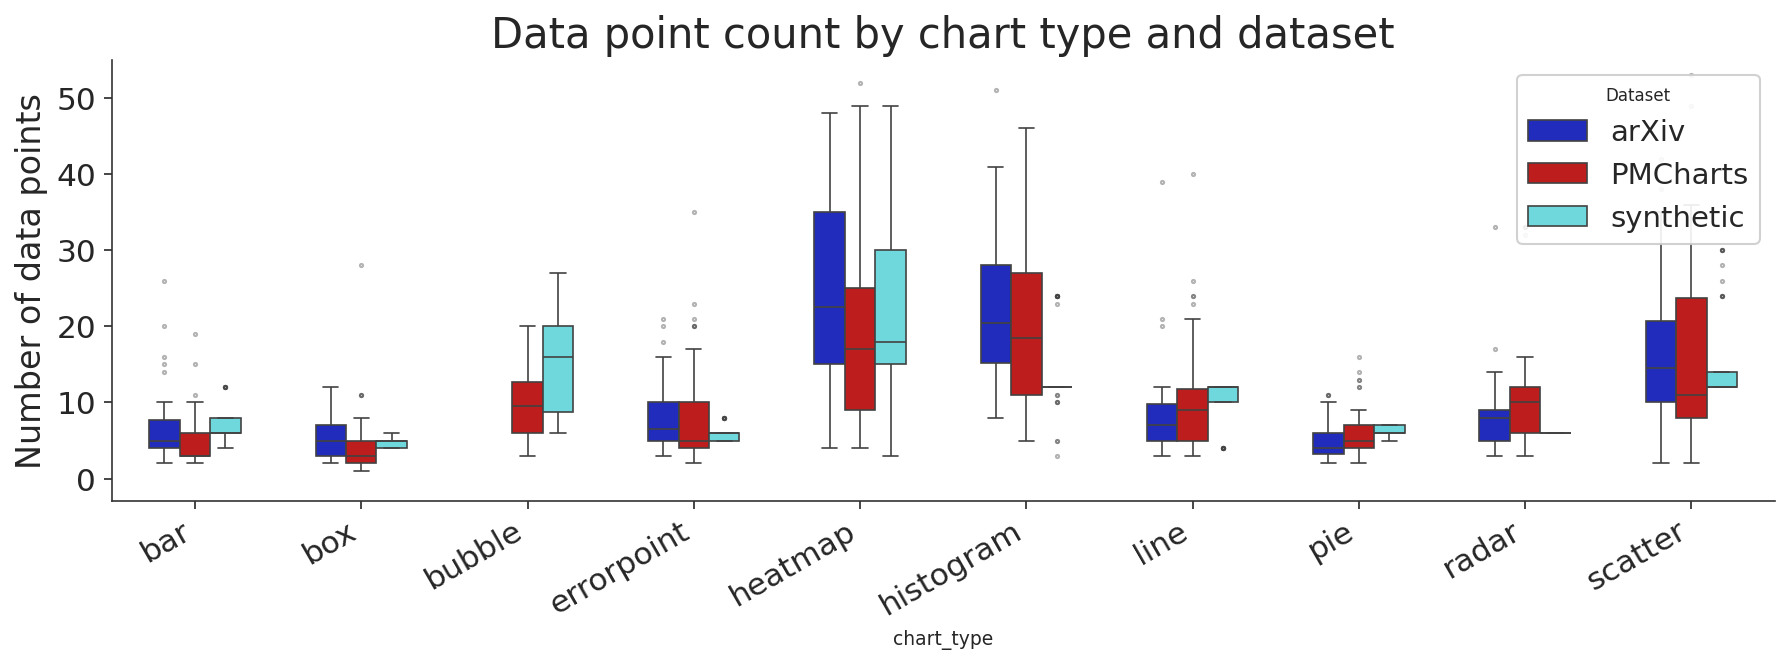

In [29]:
ct_order = sorted(df["chart_type"].unique())
fig, ax = plt.subplots(figsize=(12, 4.5))
sns.boxplot(
    data=df, x="chart_type", y="n_datapoints", hue="dataset",
    order=ct_order, hue_order=DATASETS, palette=PALETTE,
    width=0.55, linewidth=0.8,
    flierprops=dict(marker=".", markersize=3, alpha=0.4),
    ax=ax,
)
ax.set_xticks(range(len(ct_order)))
ax.set_xticklabels(ct_order, rotation=30, ha="right", fontsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel("Number of data points", fontsize=16)
ax.set_title("Data point count by chart type and dataset", fontsize=20)
ax.legend(title="Dataset", title_fontsize=8, loc="upper right", fontsize=14)
ax.set_ylim(top=55)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../outputs/fig4_datapoints_by_type.png", bbox_inches="tight")
plt.show()